# BUSCO analysis
I want to vet the new reference genome release for *Crassostrea virginica*, so I'm going to look at and compare the genomes with [BUSCO](https://busco.ezlab.org/). 

**BUSCO (Benchmarking Universal Single-Copy Orthologs)**
- evaluates genome assembly and annotation completeness by searching for a set of highly-conserved, single-copy genes specific to a lineage.

all of the code below is run in command line

## 0. create env

In [ ]:
module load conda/latest
conda create -n busco-env -c conda-forge -c bioconda busco
conda activate busco-env

## 2. download lineage dataset
mollusca is the closest to *C. virginica*

In [ ]:
busco --download mollusca_odb12

## 3. run BUSCO
submit as job

In [ ]:
#!/bin/bash
#SBATCH --job-name=busco_array
#SBATCH --cpus-per-task=16
#SBATCH --mem=64G
#SBATCH --time=24:00:00
#SBATCH --array=0-2
#SBATCH --output=busco_%A_%a.out

##---------load envs---------##

module load conda/latest
conda activate busco-env

##---------inputs---------##

GENOME_LIST=/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/compareGenomes/genomes.txt

GENOME=$(sed -n "$((SLURM_ARRAY_TASK_ID+1))p" "$GENOME_LIST")

BASENAME=$(basename "$GENOME")
BASENAME=${BASENAME%.*}

DOWNLOAD_PATH=/work/pi_sarah_gignouxwolfsohn_uml_edu/julia_mcdonough_student_uml_edu/busco_downloads

echo "Processing: $GENOME"

if [ ! -f "$GENOME" ]; then
  echo "ERROR: missing file $GENOME"
  exit 1
fi

##---------BUSCO---------##

busco \
  -i "$GENOME" \
  -l mollusca_odb10 \
  --download_path "$DOWNLOAD_PATH" \
  -o "${BASENAME}_busco" \
  -m genome \
  -c 16

## 4. visualize results
following [BUSCO documentation](https://busco.ezlab.org/busco_userguide.html#interpreting-the-results)

first need to copy all .json files into one dir: `busco_plots/`

then can run:

In [ ]:
busco --plot busco_plots

jpg file is generated

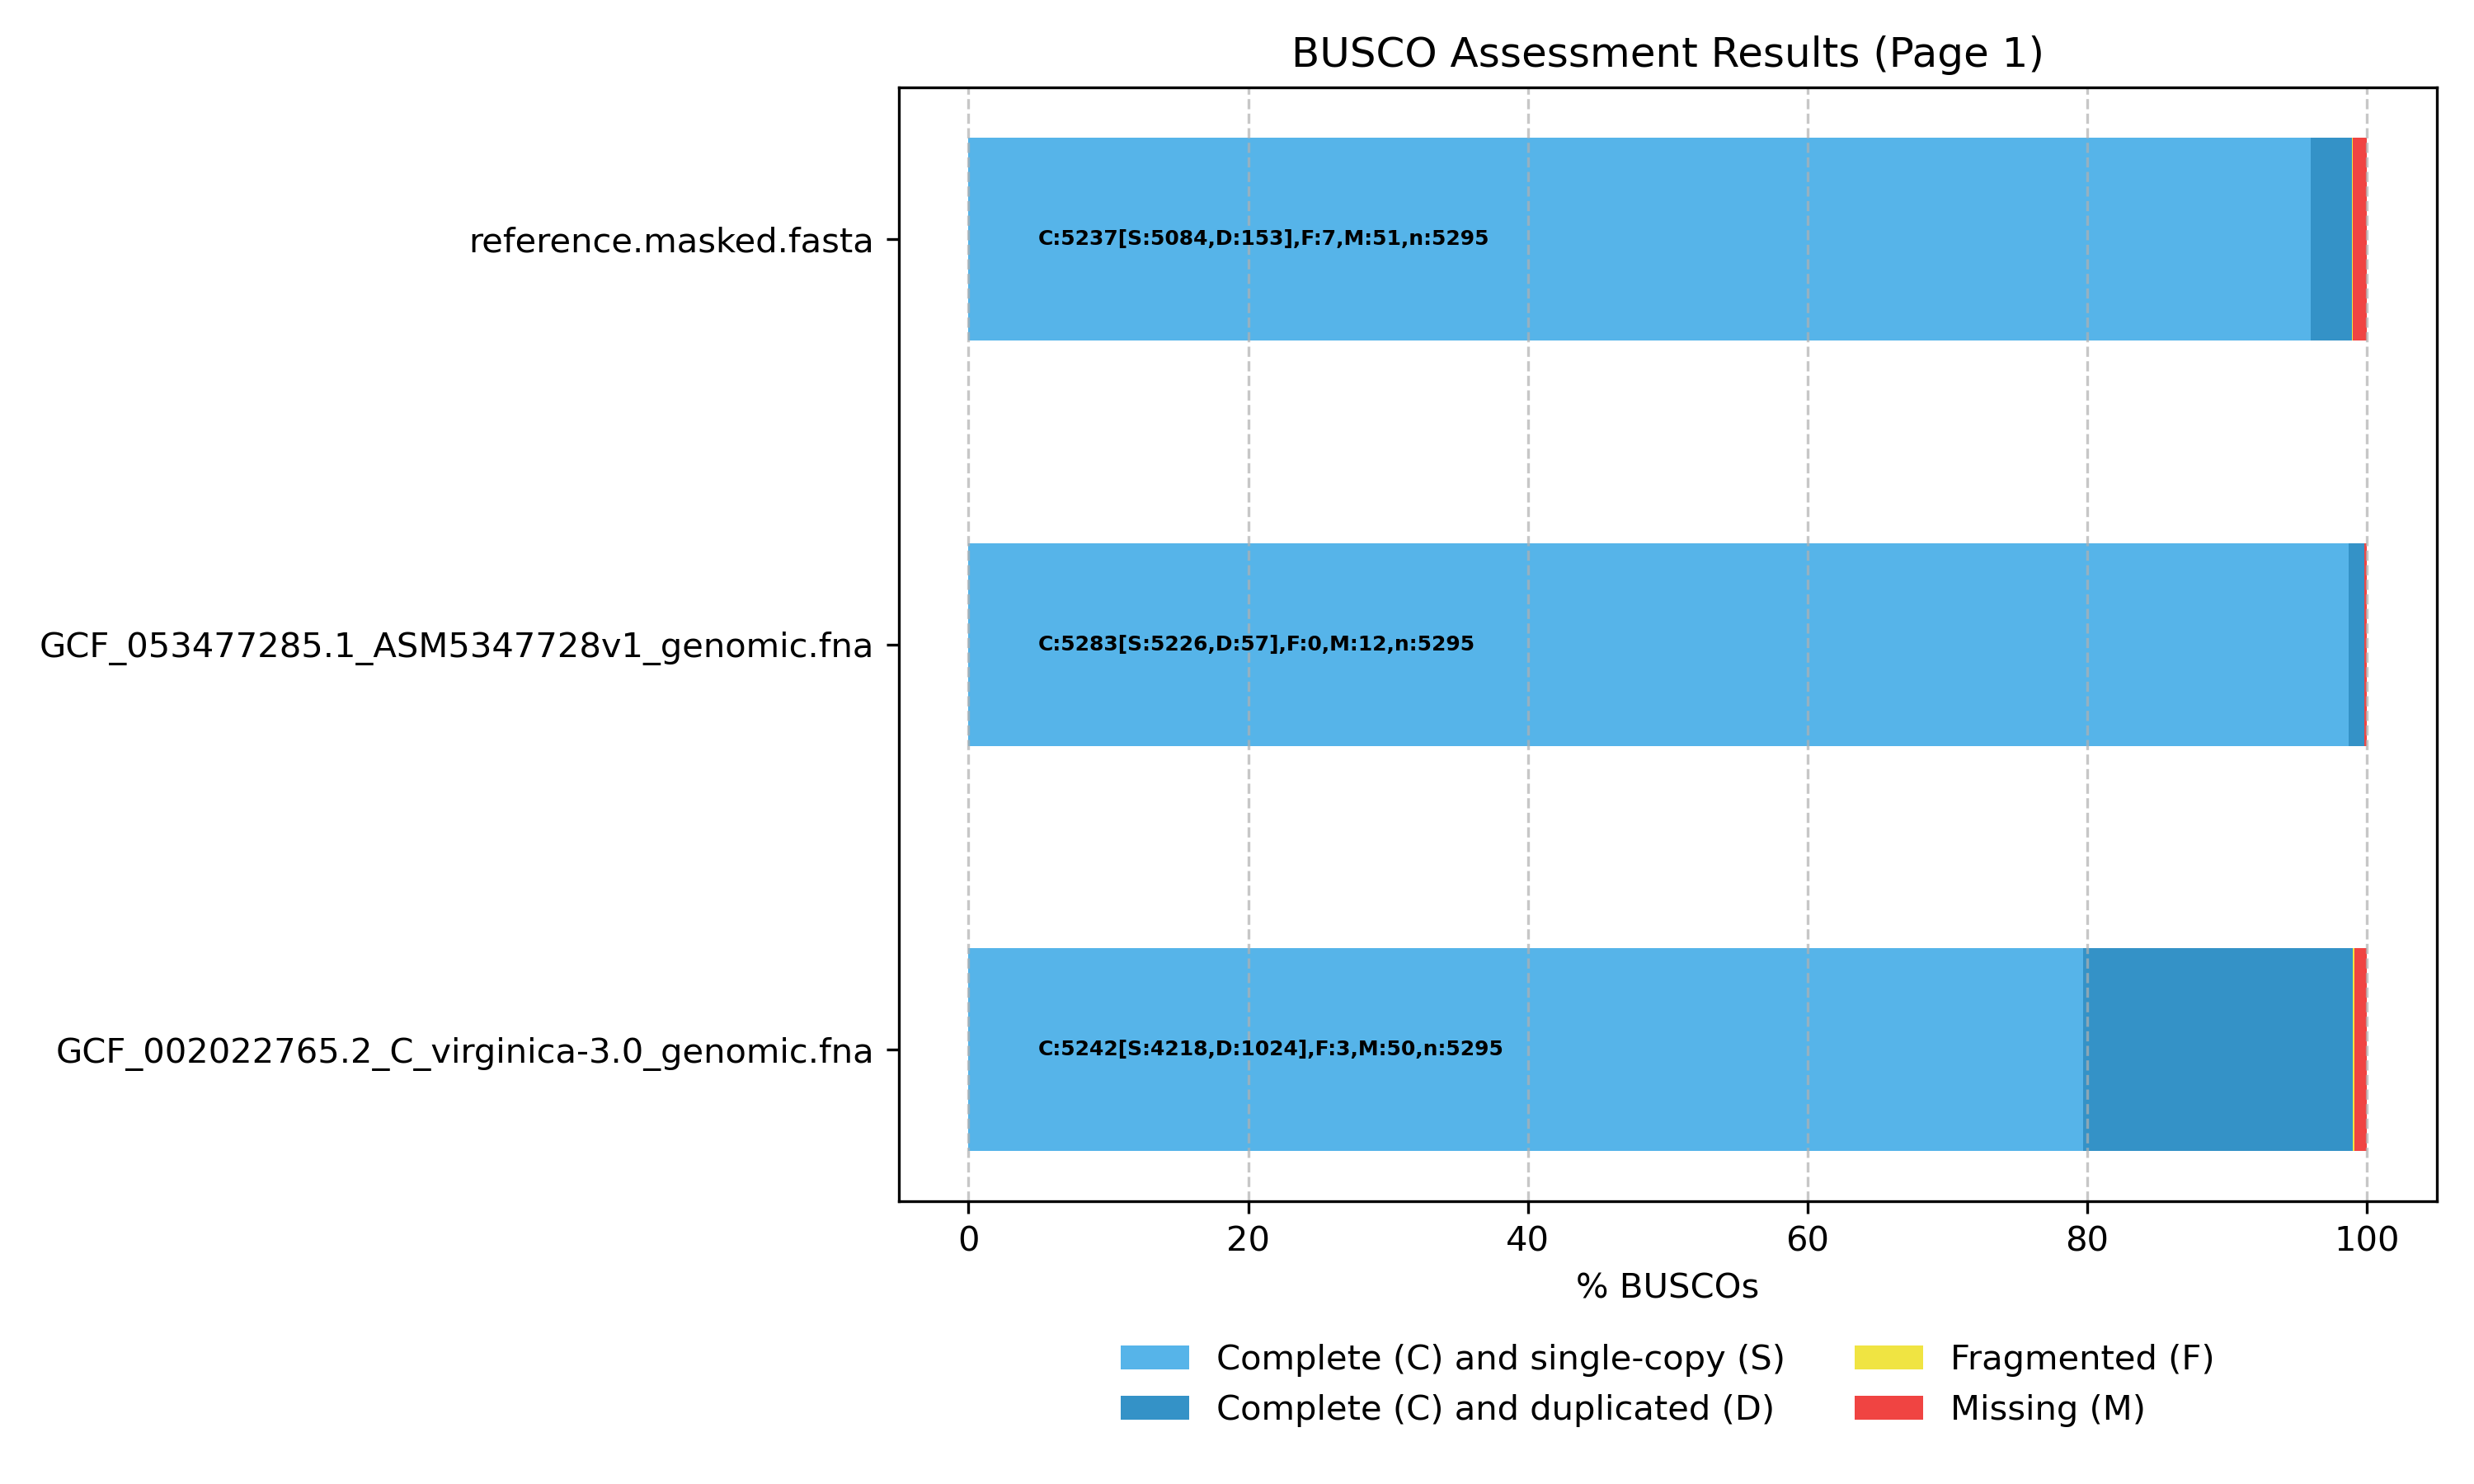

In [1]:
from IPython.display import Image, display

display(Image(filename='/work/pi_sarah_gignouxwolfsohn_uml_edu/julia_mcdonough_student_uml_edu/ce24_rnaseq/busco_output/busco_plots/busco_figure.png'))

**Genome order:**
1. haplotig masked genome
2. new 2025 reference genome release
3. old 2017 reference genome


**What do the numbers mean?**
 >BUSCO has a set of genes that are highly conserved across mollusks, almost always present, and usually present as one copy
- C: complete BUSCO genes found - most expected genes are found
    - S: single-copy - these genes were found, complete, and appeared only once
    - D: duplicated - these were found more than once - can be real (duplication events) or due to assmebly redundancy
- F: fragmented - BUSCO found only part of the gene, gene is incomplete
- M: missing - could not detect the gene at all